<h3>Use PCA to reduce the dimensionality of an image dataset and apply KNN for classification</h3>

In [22]:
import shutil
import os
import cv2
import cupy as cp
from sklearn.decomposition import PCA
from cuml.neighbors import KNeighborsClassifier
from cuml.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt



In [4]:
%pwd

'/home/hrishikesh/Desktop/AI_semII/lab_cycle_II'

In [2]:
train_csv = pd.read_csv("../datasets/butterflies/Training_set.csv")
test_csv = pd.read_csv("../datasets/butterflies/Testing_set.csv")

In [17]:
print(f"There are {len(train_csv)} training images and {len(test_csv)} testing images.")

There are 6499 training images and 2786 testing images.


In [20]:
print("Each image is of size: ")
img = cv2.imread("../datasets/butterflies/train/Image_1.jpg")
print(img.shape)

Each image is of size: 
(224, 224, 3)


In [3]:
train_csv["label"].unique().shape
train_labels = LabelEncoder().fit_transform(train_csv["label"])


In [4]:
train_labels

0       66
1        0
2       12
3       44
4       33
        ..
6494    40
6495    45
6496     4
6497    29
6498     5
Length: 6499, dtype: uint8

In [5]:
# for i in train_csv["filename"]:
#     print(i)
train_csv["label"].values

array(['SOUTHERN DOGFACE', 'ADONIS', 'BROWN SIPROETA', ..., 'APPOLLO',
       'ELBOWED PIERROT', 'ATALA'], shape=(6499,), dtype=object)

,filename
0,Image_1.jpg
1,Image_2.jpg
2,Image_3.jpg
3,Image_4.jpg
4,Image_5.jpg
...,...
2781,Image_2782.jpg
2782,Image_2783.jpg
2783,Image_2784.jpg
2784,Image_2785.jpg


Creating training images set

In [5]:
images = []
for filename in train_csv["filename"]:
    image = cv2.imread(os.path.join("../datasets/butterflies/train", filename), cv2.IMREAD_GRAYSCALE)
    image = cv2.normalize(image, None, 0, 1, cv2.NORM_MINMAX, cv2.CV_32F)
    image = image.flatten()
    images.append(image)

# images_df = pd.DataFrame(images)




Creating test images set

In [16]:
test_images = []
for filename in test_csv["filename"]:
    image = cv2.imread(os.path.join("../datasets/butterflies/test", filename), cv2.IMREAD_GRAYSCALE)
    image = cv2.normalize(image, None, 0, 1, cv2.NORM_MINMAX, cv2.CV_32F)
    image = image.flatten()
    test_images.append(image)

In [6]:
images

[array([0.14516129, 0.14516129, 0.14516129, ..., 0.21370967, 0.22177419,
        0.22580644], shape=(50176,), dtype=float32),
 array([0.53937006, 0.5590551 , 0.5826772 , ..., 0.4606299 , 0.4448819 ,
        0.42125985], shape=(50176,), dtype=float32),
 array([0.9090909, 0.9090909, 0.9090909, ..., 0.9090909, 0.9132231,
        0.9132231], shape=(50176,), dtype=float32),
 array([0.8941177 , 0.9058824 , 0.9176471 , ..., 0.90196085, 0.8980393 ,
        0.8941177 ], shape=(50176,), dtype=float32),
 array([0.9843138, 0.9843138, 0.9843138, ..., 0.9725491, 0.9725491,
        0.9686275], shape=(50176,), dtype=float32),
 array([0.25882354, 0.25882354, 0.2627451 , ..., 0.454902  , 0.4784314 ,
        0.48235297], shape=(50176,), dtype=float32),
 array([0.136     , 0.132     , 0.128     , ..., 0.22000001, 0.224     ,
        0.23200001], shape=(50176,), dtype=float32),
 array([0.5126051, 0.5126051, 0.5126051, ..., 0.6680673, 0.6680673,
        0.6680673], shape=(50176,), dtype=float32),
 array([0.

In [26]:
test_images

[array([0.07450981, 0.10980393, 0.07450981, ..., 0.13333334, 0.59607846,
        0.7411765 ], shape=(50176,), dtype=float32),
 array([0.0627451 , 0.0509804 , 0.07058824, ..., 0.6745098 , 0.7843138 ,
        0.7725491 ], shape=(50176,), dtype=float32),
 array([0.48235297, 0.46274513, 0.42352945, ..., 0.47058827, 0.454902  ,
        0.427451  ], shape=(50176,), dtype=float32),
 array([0.9527559 , 0.9527559 , 0.9527559 , ..., 0.87795275, 0.87795275,
        0.87795275], shape=(50176,), dtype=float32),
 array([0.63529414, 0.6156863 , 0.73333335, ..., 0.2392157 , 0.37254903,
        0.2901961 ], shape=(50176,), dtype=float32),
 array([0.2857143 , 0.2857143 , 0.2857143 , ..., 0.05042017, 0.05042017,
        0.05042017], shape=(50176,), dtype=float32),
 array([0.9960785, 0.9960785, 1.       , ..., 1.       , 1.       ,
        1.       ], shape=(50176,), dtype=float32),
 array([0.13438736, 0.15810278, 0.18181819, ..., 0.24901187, 0.2332016 ,
        0.26482216], shape=(50176,), dtype=float32)

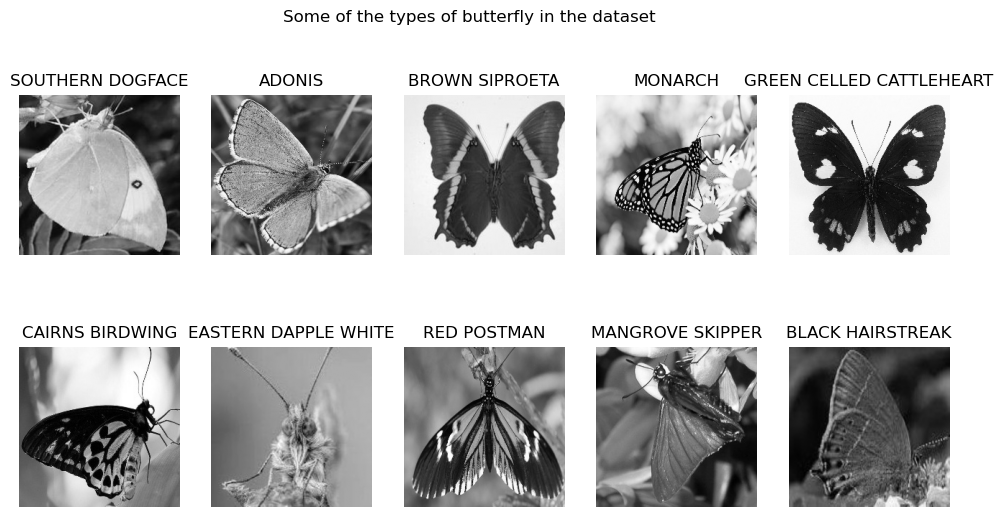

In [8]:
i=0
plt.subplots(2, 5, figsize=(12, 6))
plt.suptitle("Some of the types of butterfly in the dataset", fontsize=12)
for class_name in train_csv["label"].unique()[0:10]:
    image = train_csv[train_csv["label"] == class_name]["filename"].values[0]
    image = cv2.imread(os.path.join("../datasets/butterflies/train", image), cv2.IMREAD_GRAYSCALE)
    plt.subplot(2, 5, i+1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")
    i += 1


In [12]:
images_cp = cp.array(images)

In [7]:
pca = PCA(74)
images_pca = pca.fit_transform(images)


In [27]:
test_images_pca = pca.transform(test_images)

In [11]:
images_pca

array([[-17.4049561 ,  44.69838043,  11.66104723, ...,  -0.68320232,
         -0.55433249,   6.35282763],
       [-10.11815959,  15.75895399,   4.87571978, ...,  -0.23842059,
          0.68548998,  -3.19162678],
       [ 49.95075093, -20.53123857,   0.30278138, ...,   5.00619114,
         -0.61144323,   4.85047706],
       ...,
       [-38.9982982 ,  17.05829728,  -0.30478211, ...,  -2.0640029 ,
          0.58524047,  -1.20152259],
       [ 58.41100174,  21.92856144,  -8.44585236, ...,  -0.23060812,
         -0.50116658,   3.65543845],
       [ -7.47025629, -35.87966307, -12.56233503, ...,  -0.69694074,
          2.39800355,  -2.15930186]], shape=(6499, 74))

Training a KNN classifier on the original images dataset

In [13]:
knn_01 = KNeighborsClassifier(N_neighbors=4, metric="euclidean")

In [14]:
knn_01.fit(images_cp, train_labels)

KNeighborsClassifier()

Training a KNN Classifier on the PCA applied images which has 74 components

In [15]:
knn_02 = KNeighborsClassifier(N_neighbors=4, metric="euclidean")
knn_02.fit(cp.array(images_pca), train_labels)

KNeighborsClassifier()

Comparing the performances of both KNN models

In [ ]:
test_01 = knn_01.predict(cp.array(test_images))

In [28]:
test_02 = knn_02.predict(cp.array(test_images_pca))

In [29]:
print("The classification report for the first KNN model is:")
print(classification_report(cp.asnumpy(test_01), test_csv["label"].values))

The classification report for the first KNN model is:


KeyError: 'label'